In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x +5

In [3]:
print(f(5))

60


In [4]:
x_series = np.arange(1,15,2)

In [5]:
x_series

array([ 1,  3,  5,  7,  9, 11, 13])

In [6]:
y_series = f(x_series)

In [7]:
y_series

array([  4,  20,  60, 124, 212, 324, 460])

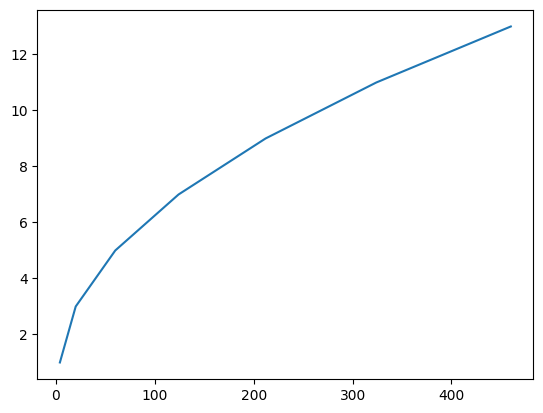

In [8]:
plt.plot(y_series,x_series)
plt.show()

In [9]:
x=3.0
h=0.000000000000001
(f(x+h)-f(x))/h

10.658141036401503

In [10]:
class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0
        # internal variables used for autograd graph construction
        self._prev = set(_children)
        self._op = _op # the op that produced this node, for graphviz / debugging / etc
    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out
    def __truediv__(self, other): # self / other
        out = Value (self.data * other.data**-1,(self,other),'/')
        return out


In [11]:
a= Value(5)
b=Value(4)

In [12]:
a,b

(Value(data=5, grad=0), Value(data=4, grad=0))

In [13]:
c=a+b


In [14]:
c._op

'+'

In [15]:
c._prev

{Value(data=4, grad=0), Value(data=5, grad=0)}

In [16]:
from graphviz import Digraph

In [17]:

def trace(root):
    ## Builds out the entire calculation in a graph
    nodes,edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges


def draw_dot(root):
    dot = Digraph(format='svg',graph_attr = {'rankdir':'LR'})
    nodes,edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        # for any value in the graph create a rectangular box to indcate a value 
        dot.node(name=uid, label = "{data %.4f}" %(n.data,), shape = 'record')

        if n._op:
            dot.node(name=uid+n._op, label = n._op)
            dot.edge(uid+n._op,n._op)

    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2))+n2._op)

    return dot

In [18]:
draw_dot(c)

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH